# 01 · EDA — 암종 분류 (트랙 B)

- **Owner**: member_d
- **목적**: 데이터 로드부터 제출 파일 생성까지 **한 바퀴를 끊김 없이** 돌려, 작업 프로세스가 재현 가능한지 검증한다
- **비교 대상**: 같은 코드를 별도 환경에서 돌린 결과와 수치가 일치하는지 확인
- **Seed / Validation**: 섹션 6에서 명시

## 진행 방식

한 섹션을 돌린 뒤 **체크포인트 셀의 표와 본인 출력이 일치하는지** 확인하고 다음 섹션으로 넘어간다.
불일치가 나오면 그 자리에서 멈추고 원인을 찾는다 — 뒤에서 발견하면 어디서 갈렸는지 추적이 어렵다.

## 로드맵

| 섹션 | 내용 | 상태 |
|---|---|---|
| 1 | 환경 · 경로 · 로드 검증 | ✅ 검증 완료 |
| 2 | 라벨 구조 — 26클래스 분포와 TCGA 중첩 | ✅ 검증 완료 |
| 3 | 피처 구조 — 희소성 · 변이 표기 형태 | ✅ 검증 완료 |
| 4 | TMB (샘플당 변이 개수) | ✅ 검증 완료 |
| 5 | Leakage-safe 전처리 | ✅ 검증 완료 |
| 6 | CV 베이스라인 (StratifiedKFold-5) | ✅ 검증 완료 |
| 7 | submission · metrics.json 생성 | ✅ 검증 완료 |
| 8 | 재현성 자가점검 | ✅ 검증 완료 |

> 각 섹션의 표와 그림은 `artifacts/` 에 저장한다. 이후 **EDA 상세 보고서**를 만들 때 그대로 가져다 쓰기 위함이다.


---
## Section 1 · 환경 · 경로 · 로드 검증

여기서 확인하는 것은 네 가지다.

1. 실행 환경(파이썬·라이브러리 버전)이 팀 기준과 맞는가
2. 저장소 루트를 자동으로 찾는가 — 개인 PC 절대경로를 쓰지 않기 위함
3. 파일 3개가 규약 위치(`data/raw/`)에 있는가
4. **데이터의 기본 스펙이 공지와 일치하는가** — 여기서 어긋나면 이후 전부 무의미


In [185]:
import sys, platform
import numpy as np
import pandas as pd
import sklearn

print("Python  :", sys.version.split()[0], "|", platform.system())
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("sklearn :", sklearn.__version__)

Python  : 3.12.13 | Darwin
pandas  : 2.3.3
numpy   : 2.5.1
sklearn : 1.9.0


In [186]:
from pathlib import Path


def find_project_root(start: Path) -> Path:
    """configs/baseline.yaml 을 기준점으로 저장소 루트를 찾는다.
    노트북을 어디서 열어도 동작하며, 개인 PC 절대경로를 코드에 쓰지 않게 해준다."""
    for path in [start, *start.parents]:
        if (path / "configs" / "baseline.yaml").exists():
            return path
    raise FileNotFoundError(
        "저장소 루트를 찾지 못했습니다. JupyterLab을 레포 루트에서 실행하세요."
    )


ROOT = find_project_root(Path.cwd())
DATA = ROOT / "data" / "raw"
NB = "01"                                  # 이 노트북의 번호 — artifacts 파일명 접두로 사용
ARTIFACTS = ROOT / "experiments" / "member_d" / "notebooks" / "artifacts"       # 표·그림은 커밋, 대용량 spec 은 제외
ARTIFACTS.mkdir(parents=True, exist_ok=True)

print("ROOT      :", ROOT)
print("DATA      :", DATA)
print("ARTIFACTS :", ARTIFACTS)
print()
for name in ["train.csv", "test.csv", "sample_submission.csv"]:
    p = DATA / name
    mark = "OK" if p.exists() else "MISSING"
    size = f"{p.stat().st_size / 1e6:8.1f} MB" if p.exists() else ""
    print(f"{name:22} {mark:8} {size}")

ROOT      : /Volumes/DataSSD/AI_health_care_5/25_aiCancerClassification
DATA      : /Volumes/DataSSD/AI_health_care_5/25_aiCancerClassification/data/raw
ARTIFACTS : /Volumes/DataSSD/AI_health_care_5/25_aiCancerClassification/experiments/member_d/notebooks/artifacts

train.csv              OK           82.6 MB
test.csv               OK           35.1 MB
sample_submission.csv  OK            0.0 MB


In [187]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
submission = pd.read_csv(DATA / "sample_submission.csv")

print("train      :", train.shape)
print("test       :", test.shape)
print("submission :", submission.shape)

train      : (6201, 4386)
test       : (2546, 4385)
submission : (2546, 2)


In [188]:
# 스키마 정합성 — 여기가 깨져 있으면 뒤의 모든 전처리가 어긋난다
TARGET = "SUBCLASS"
ID = "ID"

gene_cols = [c for c in train.columns if c not in (TARGET, ID)]
test_gene_cols = [c for c in test.columns if c != ID]

print("train 컬럼 앞 5개 :", list(train.columns[:5]))
print("test  컬럼 앞 5개 :", list(test.columns[:5]))
print()
print("유전체 컬럼 수                :", len(gene_cols))
print("train/test 컬럼 이름·순서 동일 :", gene_cols == test_gene_cols)
print("SUBCLASS 는 train 에만 존재    :", TARGET in train.columns and TARGET not in test.columns)
print()
print("ID 중복 train :", int(train[ID].duplicated().sum()),
      "| test :", int(test[ID].duplicated().sum()))
print("test ID 와 submission ID 순서까지 일치 :",
      bool((test[ID].values == submission[ID].values).all()))
print("클래스 수 :", train[TARGET].nunique())

train 컬럼 앞 5개 : ['ID', 'SUBCLASS', 'A2M', 'AAAS', 'AADAT']
test  컬럼 앞 5개 : ['ID', 'A2M', 'AAAS', 'AADAT', 'AARS1']

유전체 컬럼 수                : 4384
train/test 컬럼 이름·순서 동일 : True
SUBCLASS 는 train 에만 존재    : True

ID 중복 train : 0 | test : 0
test ID 와 submission ID 순서까지 일치 : True
클래스 수 : 26


In [189]:
# 결측치 — train 과 test 를 따로 본다
n_tr = int(train.isna().sum().sum())
n_te = int(test.isna().sum().sum())
print(f"결측치  train {n_tr}  |  test {n_te}")

if n_te:
    na_col = test.isna().sum()
    na_col = na_col[na_col > 0].sort_values(ascending=False)
    na_row = test.isna().sum(axis=1)
    print(f"\ntest 결측 컬럼 {len(na_col)}개 / 결측 행 {int((na_row > 0).sum())}개 "
          f"(행당 최대 {int(na_row.max())}개)")
    print(na_col.head(10).to_string())

결측치  train 0  |  test 237

test 결측 컬럼 25개 / 결측 행 128개 (행당 최대 5개)
CNOT2      77
TNFAIP6    65
AK2        29
MYL1       21
RBM5       19
TMEM97      4
PTGES3      3
CCRL2       2
CFP         1
PTCH1       1


In [190]:
# 셀 값이 실제로 어떻게 생겼는지 — 전처리 방식을 정하기 전에 눈으로 본다
sample_cols = gene_cols[:50]
values = pd.unique(train[sample_cols].values.ravel())
print("값 예시 :", list(values[:8]))
print("고유값 개수(앞 50열):", len(values))
print("WT 비율(앞 50열)    :", round(float((train[sample_cols].values == "WT").mean()), 4))
print()
print("한 칸에 변이가 여러 개 들어간 예시:")
multi = [v for v in values if isinstance(v, str) and " " in v][:5]
print(multi)

값 예시 : ['WT', 'D623D', 'T1115M', 'R895R', 'T426T', 'D655N', 'I489I', 'S27N']
고유값 개수(앞 50열): 3923
WT 비율(앞 50열)    : 0.9864

한 칸에 변이가 여러 개 들어간 예시:
['F157L S1042F', 'G458G E135K', 'G1432R C1201Y', 'S824L R130I', 'T1537M D462Y F135L']


### ✅ Section 1 체크포인트

아래는 **별도 환경(Linux · Python 3.11 · pandas 3.0.2 · numpy 2.4.4 · sklearn 1.8.0)** 에서 나온 값이다.
본인 출력과 대조한다. 라이브러리 버전은 달라도 되지만, **데이터 관련 수치는 전부 같아야 한다.**

| 항목 | 기준값 |
|---|---|
| `train.shape` | **(6201, 4386)** |
| `test.shape` | **(2546, 4385)** |
| `submission.shape` | (2546, 2) |
| 유전체 컬럼 수 | **4384** |
| train/test 컬럼 이름·순서 동일 | True |
| ID 중복 | train 0 · test 0 |
| test ID ↔ submission ID 순서 일치 | True |
| 클래스 수 | **26** |
| 결측치 train | **0** |
| 결측치 test | **237** (25개 컬럼, 128개 행) |

### 이번 섹션에서 나온 것

**1. 대회 설명문의 "6,199개 유전자"는 실제와 다르다.** 파일 기준 유전체 컬럼은 **4,384개**다. 문서가 아니라 `df.shape` 를 믿는다.

**2. test 에만 결측치가 237개 있다.** train 은 0개다. 최다는 `CNOT2` 77개, `TNFAIP6` 65개 순이고, 128개 행에 걸쳐 있다.

이게 왜 중요한가 — 전처리를 `!= "WT"` 로만 짜면 **NaN 이 조용히 "변이 있음(True)" 으로 처리된다.** train 에는 결측이 없으니 학습 중에는 절대 드러나지 않고, test 추론에서만 128개 행이 오염된다. 반드시 `.fillna("WT")` 를 먼저 거쳐야 한다. (팀장 README의 `transform()` 이 `.fillna("WT")` 를 넣어둔 이유가 이것으로 보인다.)

**3. 한 칸에 변이가 여러 개 들어갈 수 있다.** `"A1061V I1056I"` 처럼 공백으로 구분된다. 단순 이진화는 이 정보를 버린다 — 섹션 3에서 다룬다.

---

**다음** — 확인이 끝나면 알려주세요. Section 2 (라벨 구조)를 이어서 작성하겠습니다.


---
## Section 2 · 라벨 구조 — 26클래스 분포와 TCGA 중첩

평가 지표가 **Macro F1** 이라는 사실이 이 섹션의 전부를 규정한다.
Macro F1 은 클래스별 F1 의 **단순 평균**이므로, 샘플이 38개뿐인 클래스도 786개인 클래스와 **똑같은 지분**을 갖는다.

여기서 확인할 것:

1. 클래스별 샘플 수와 불균형 정도
2. `StratifiedKFold(5)` 가 경고 없이 돌아가는가 — 최소 클래스가 fold 당 몇 개인가
3. **라벨이 서로 배타적인가** — SUBCLASS 는 TCGA 코호트 코드이고, 일부는 다른 라벨을 포함하는 집합이다


In [191]:
# 클래스 분포
class_counts = train[TARGET].value_counts().sort_values(ascending=False)
n_class = len(class_counts)

print(f"클래스 수 : {n_class}")
print(f"최다      : {class_counts.index[0]} {class_counts.iloc[0]}개")
print(f"최소      : {class_counts.index[-1]} {class_counts.iloc[-1]}개")
print(f"불균형비  : {class_counts.max() / class_counts.min():.2f}배")
print(f"중앙값    : {class_counts.median():.0f}개")
print()
print(class_counts.to_string())

# 보고서용 저장
class_counts.rename("n").to_csv(ARTIFACTS / f"{NB}_s2_class_counts.csv", encoding="utf-8-sig")

클래스 수 : 26
최다      : BRCA 786개
최소      : DLBC 38개
불균형비  : 20.68배
중앙값    : 198개

SUBCLASS
BRCA      786
KIPAN     515
GBMLGG    461
STES      379
KIRC      334
THCA      324
SKCM      276
PRAD      266
OV        253
LGG       229
HNSC      223
COAD      223
UCEC      198
SARC      198
LUAD      184
LUSC      178
LAML      158
LIHC      158
CESC      155
PCPG      147
TGCT      124
PAAD      120
BLCA      104
THYM       98
ACC        72
DLBC       38


In [192]:
# Macro F1 관점에서의 지분과 CV 실행 가능성
share = 100 / n_class
min_n = int(class_counts.min())

print(f"클래스 하나당 Macro F1 지분 : {share:.2f} %")
print(f"최소 클래스 fold 당 샘플 수 : {min_n / 5:.1f}개  (StratifiedKFold(5) 기준)")
print()
print("→ 5개 미만 클래스가 없으므로 StratifiedKFold(5) 는 경고 없이 동작한다."
      if min_n >= 5 else "→ 경고 발생 위험. n_splits 재검토 필요.")
print()

# 소수 클래스 몇 개가 점수의 얼마를 좌우하는가
small = class_counts[class_counts < 160]
print(f"샘플 160개 미만 클래스 {len(small)}개가 Macro F1 의 "
      f"{len(small) * share:.1f}% 를 차지한다:")
print("  " + ", ".join(f"{k}({v})" for k, v in small.items()))

클래스 하나당 Macro F1 지분 : 3.85 %
최소 클래스 fold 당 샘플 수 : 7.6개  (StratifiedKFold(5) 기준)

→ 5개 미만 클래스가 없으므로 StratifiedKFold(5) 는 경고 없이 동작한다.

샘플 160개 미만 클래스 10개가 Macro F1 의 38.5% 를 차지한다:
  LAML(158), LIHC(158), CESC(155), PCPG(147), TGCT(124), PAAD(120), BLCA(104), THYM(98), ACC(72), DLBC(38)


In [193]:
# SUBCLASS 는 TCGA study abbreviation 이다. 일부는 다른 코드를 포함하는 '집합' 코드.
TCGA_AGGREGATES = {
    "KIPAN": ["KICH", "KIRC", "KIRP"],   # Pan-kidney
    "GBMLGG": ["GBM", "LGG"],            # Glioma 통합
    "STES": ["STAD", "ESCA"],            # Stomach + Esophageal
    "COADREAD": ["COAD", "READ"],        # Colorectal
}

present = set(class_counts.index)
overlapping = []

for agg, members in TCGA_AGGREGATES.items():
    if agg not in present:
        print(f"{agg:9} — 라벨에 없음. 무시")
        continue
    inside = [m for m in members if m in present]
    if inside:
        overlapping += [agg] + inside
        print(f"{agg:9} 존재 · 구성원도 함께 존재 → {inside}   ⚠️ 포함 관계")
    else:
        print(f"{agg:9} 존재 · 구성원 없음 → 사실상 독립 클래스로 취급 가능")

overlapping = sorted(set(overlapping))
print()
print(f"포함 관계에 얽힌 클래스 {len(overlapping)}개 : {overlapping}")
print(f"→ Macro F1 의 {len(overlapping) * share:.1f}% 가 여기에 걸려 있다")

KIPAN     존재 · 구성원도 함께 존재 → ['KIRC']   ⚠️ 포함 관계
GBMLGG    존재 · 구성원도 함께 존재 → ['LGG']   ⚠️ 포함 관계
STES      존재 · 구성원 없음 → 사실상 독립 클래스로 취급 가능
COADREAD  — 라벨에 없음. 무시

포함 관계에 얽힌 클래스 4개 : ['GBMLGG', 'KIPAN', 'KIRC', 'LGG']
→ Macro F1 의 15.4% 가 여기에 걸려 있다


In [194]:
# 데이터가 실제로 그 구조를 보여주는가 — 클래스별 평균 변이 프로파일 유사도
# (fillna("WT") 는 Section 1 에서 확인한 test 결측 대응. 여기서는 train 이라 무해하지만 습관화한다)
Xb = (train[gene_cols].fillna("WT").values != "WT").astype(np.float32)
classes = sorted(class_counts.index)

profiles = np.vstack([Xb[train[TARGET].values == c].mean(axis=0) for c in classes])
profiles_n = profiles / np.linalg.norm(profiles, axis=1, keepdims=True)
sim = profiles_n @ profiles_n.T

pairs = [(classes[i], classes[j], float(sim[i, j]))
         for i in range(len(classes)) for j in range(i + 1, len(classes))]
pairs.sort(key=lambda t: -t[2])

print("평균 변이 프로파일 코사인 유사도 — 상위 8쌍")
for a, b, s in pairs[:8]:
    flag = "  ← 포함 관계" if (a in overlapping and b in overlapping) else ""
    print(f"  {a:8} {b:8} {s:.4f}{flag}")

pd.DataFrame(pairs, columns=["a", "b", "cosine"]).to_csv(
    ARTIFACTS / f"{NB}_s2_class_similarity.csv", index=False, encoding="utf-8-sig")

평균 변이 프로파일 코사인 유사도 — 상위 8쌍
  KIPAN    KIRC     0.9097  ← 포함 관계
  GBMLGG   LGG      0.8931  ← 포함 관계
  LUSC     STES     0.8736
  LUAD     LUSC     0.8563
  COAD     STES     0.8455
  HNSC     LUSC     0.8446
  STES     UCEC     0.8426
  LUAD     STES     0.8421


In [195]:
# 중첩 쌍을 유전자 하나로 가를 수 있는가
def discriminative(a, b, min_rate=0.15, ratio=3.0):
    """a 에서 min_rate 이상 변이가 나면서, b 대비 ratio 배 이상 높은 유전자."""
    ia = train[TARGET].values == a
    ib = train[TARGET].values == b
    found = []
    for k, gene in enumerate(gene_cols):
        pa = Xb[ia, k].mean()
        pb = Xb[ib, k].mean()
        if pa >= min_rate and pa > ratio * max(pb, 1e-9):
            found.append((gene, round(float(pa), 3), round(float(pb), 3)))
    return found


for a, b in [("KIPAN", "KIRC"), ("KIRC", "KIPAN"), ("GBMLGG", "LGG"), ("LGG", "GBMLGG")]:
    d = discriminative(a, b)
    print(f"{a:7} > {b:7} : {len(d)}개  {d[:3]}")

KIPAN   > KIRC    : 0개  []
KIRC    > KIPAN   : 0개  []
GBMLGG  > LGG     : 1개  [('PTEN', 0.163, 0.035)]
LGG     > GBMLGG  : 0개  []


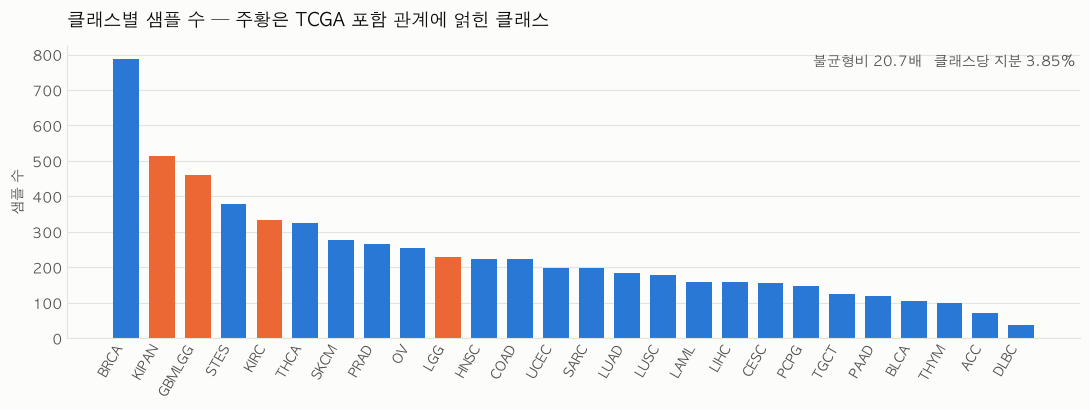

In [196]:
import matplotlib
import matplotlib.pyplot as plt

# 한글 폰트 — 환경마다 다르므로 있는 것을 골라 쓴다 (없으면 그림의 한글만 깨지고 수치는 정상)
for cand in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if any(f.name == cand for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = cand
        break
plt.rcParams["axes.unicode_minus"] = False

SURF, INK, SUB2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, ORANGE, GRID = "#2a78d6", "#eb6834", "#e4e3e0"

fig, ax = plt.subplots(figsize=(11, 4.2))
fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)

colors = [ORANGE if c in overlapping else BLUE for c in class_counts.index]
ax.bar(range(n_class), class_counts.values, color=colors, width=0.72)

ax.set_xticks(range(n_class))
ax.set_xticklabels(class_counts.index, rotation=60, ha="right", fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.yaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.tick_params(colors=SUB2, length=0)
ax.set_ylabel("샘플 수", color=SUB2, fontsize=10)
ax.set_title("클래스별 샘플 수 — 주황은 TCGA 포함 관계에 얽힌 클래스",
             loc="left", color=INK, fontsize=13, fontweight="bold", pad=14)
ax.text(0.995, 0.93, f"불균형비 {class_counts.max() / class_counts.min():.1f}배   "
                     f"클래스당 지분 {share:.2f}%",
        transform=ax.transAxes, ha="right", color=SUB2, fontsize=10)

fig.tight_layout()
fig.savefig(ARTIFACTS / f"{NB}_s2_class_distribution.png", dpi=200, facecolor=SURF)
plt.show()

### ✅ Section 2 체크포인트

| 항목 | 기준값 |
|---|---|
| 클래스 수 | **26** |
| 최다 / 최소 | BRCA **786** / DLBC **38** |
| 불균형비 | **20.68배** |
| 클래스당 Macro F1 지분 | **3.85 %** |
| 최소 클래스 fold 당 | 7.6개 → `StratifiedKFold(5)` 정상 |
| 포함 관계 클래스 | **KIPAN, KIRC, GBMLGG, LGG (4개 = 15.4 %)** |
| 유사도 1위 | KIPAN ↔ KIRC **0.9097** |
| 유사도 2위 | GBMLGG ↔ LGG **0.8931** |
| KIPAN vs KIRC 판별 유전자 | **양쪽 다 0개** |
| GBMLGG vs LGG 판별 유전자 | GBMLGG 쪽 1개 (PTEN 16.3% vs 3.5%) |

### 이번 섹션에서 나온 것

**1. 라벨이 서로 배타적이지 않다.** `SUBCLASS` 는 TCGA study abbreviation 이고, `KIPAN = KICH+KIRC+KIRP`, `GBMLGG = GBM+LGG` 는 다른 라벨을 **포함하는 집합**이다. 실제로 데이터에 KIPAN 과 KIRC 가 **둘 다** 라벨로 존재한다. 일반적인 다중 분류의 "클래스는 서로 배타적" 가정이 깨져 있다.

**2. 데이터가 그 구조를 그대로 보여준다.** 평균 변이 프로파일 유사도 **1·2위가 정확히 그 두 쌍**이다 (0.9097 / 0.8931). 우연이 아니라 정의상 겹치는 것이다.

**3. 단일 유전자로는 가를 수 없다.** KIPAN 과 KIRC 는 어느 쪽에서도 판별 유전자가 **0개**다. 라벨링 규칙 자체(어떤 샘플을 KIRC 로, 어떤 샘플을 KIPAN 으로 적었는가)를 알아내지 않으면 변이 정보만으로는 접근이 안 된다.

**4. STES 는 다르다.** 집합 코드이긴 하나 구성원 STAD·ESCA 가 라벨에 없어서, 사실상 **독립 클래스로 취급 가능**하다. (앞선 분석에서 STES 도 중첩으로 분류했던 것을 여기서 정정한다.)

**5. 소수 클래스가 점수를 좌우한다.** 샘플 160개 미만 클래스 **10개**가 Macro F1 의 **38.5%** 를 차지한다 (LIHC·LAML·CESC·PCPG·TGCT·PAAD·BLCA·THYM·ACC·DLBC). 정확도(accuracy)를 올리는 것과 Macro F1 을 올리는 것은 완전히 다른 게임이다.

<br>

> **⚠️ 판별 유전자 수치 주의** — GBMLGG 쪽 판별 유전자는 임계값에 예민하다. 15% / 3배 기준에서 PTEN 1개만 남지만, 기준을 조금 낮추면 EGFR 이 들어온다. 절대적인 개수보다 **"거의 없다"** 는 결론이 요점이다.

---

**다음** — 확인이 끝나면 알려주세요. Section 3 (피처 구조 — 희소성과 변이 표기 형태)로 넘어가겠습니다.


---
## Section 3 · 피처 구조 — 희소성과 변이 표기 형태

지금까지는 `WT / 변이` 이진화만 써왔다. 이 섹션의 목적은 **그 이진화가 무엇을 버리고 있는지**를 수치로 확인하는 것이다.

확인할 것:

1. 행렬이 얼마나 비어 있는가 — 희소성과 상수열
2. 한 칸에 변이가 여러 개 들어가는 빈도
3. 변이 표기를 파싱하면 어떤 유형들인가 (미스센스 / 동의 / 넌센스 / 프레임시프트)
4. **변이를 그대로 피처로 쓰면 일반화되는가** — 처음 보는 변이 비율
5. 위치 정보가 실제로 클래스를 가르는가

<callout>

### ⚠️ 이 섹션의 Leakage 경계

이 섹션은 **train 만 사용한다.**

Section 1 에서 test 의 결측 **유무**를 확인한 것은 코드가 죽지 않게 하기 위한 **구조 점검**이라 허용 범위다 (`fillna("WT")` 는 test 에서 계산한 값이 아니라 상수다).
그러나 **test 의 분포 통계**(변이율, TMB 평균, 변이 어휘 구성 등)를 구해서 전처리나 피처 설계 판단에 쓰면 **Data Leakage 다.** 대회 규정에 명시된 실격 사유다.

> "Test 데이터로부터 EDA를 진행한 결과(인사이트)를 전처리·모델 학습에 적용하는 경우"

그래서 4번 "처음 보는 변이 비율" 은 test 와 비교하지 않고, **train 을 5-fold 로 나눠 held-out fold 를 '처음 보는 데이터'로 삼아** 측정한다. 같은 질문에 답하면서 규정 안에 있는 방법이다.

</callout>


In [197]:
# 행렬 희소성
X_bin = (train[gene_cols].fillna("WT").values != "WT")

print(f"전체 셀     : {X_bin.size:,}")
print(f"변이 셀     : {int(X_bin.sum()):,}")
print(f"변이 비율   : {X_bin.mean() * 100:.3f} %")
print()

gene_rate = pd.Series(X_bin.mean(axis=0), index=gene_cols)
print(f"전부 WT 인 상수열 : {int((gene_rate == 0).sum())}개  → 제거 대상")
print(f"변이율 1% 미만    : {int((gene_rate < 0.01).sum())}개  ({(gene_rate < 0.01).mean() * 100:.1f}%)")
print(f"변이율 5% 이상    : {int((gene_rate >= 0.05).sum())}개")
print()
print("변이율 상위 10개 유전자")
print((gene_rate.sort_values(ascending=False).head(10) * 100).round(2).to_string())

gene_rate.sort_values(ascending=False).rename("mutation_rate").to_csv(
    ARTIFACTS / f"{NB}_s3_gene_mutation_rate.csv", encoding="utf-8-sig")

전체 셀     : 27,185,184
변이 셀     : 218,893
변이 비율   : 0.805 %

전부 WT 인 상수열 : 154개  → 제거 대상
변이율 1% 미만    : 3329개  (75.9%)
변이율 5% 이상    : 23개

변이율 상위 10개 유전자
TP53      28.54
PIK3CA    11.06
RYR2      10.37
SYNE1     10.35
PCLO       9.56
RYR1       7.63
SPTA1      7.43
KMT2D      7.27
IDH1       7.11
BRAF       7.06


In [198]:
# 한 칸에 변이가 몇 개까지 들어가는가
mutated_cells = train[gene_cols].fillna("WT").values[X_bin]
n_variant = np.array([s.count(" ") + 1 for s in mutated_cells])

print(f"변이가 있는 칸 {len(n_variant):,}개 중")
print(f"  변이 1개  : {int((n_variant == 1).sum()):,}  ({(n_variant == 1).mean() * 100:.1f}%)")
print(f"  변이 2개  : {int((n_variant == 2).sum()):,}  ({(n_variant == 2).mean() * 100:.1f}%)")
print(f"  변이 3개+ : {int((n_variant >= 3).sum()):,}  ({(n_variant >= 3).mean() * 100:.1f}%)")
print(f"  한 칸 최대: {int(n_variant.max())}개")
print()
print("→ 이진화는 '변이 1개'와 '변이 64개'를 똑같이 1로 만든다.")

변이가 있는 칸 218,893개 중
  변이 1개  : 196,867  (89.9%)
  변이 2개  : 16,261  (7.4%)
  변이 3개+ : 5,765  (2.6%)
  한 칸 최대: 64개

→ 이진화는 '변이 1개'와 '변이 64개'를 똑같이 1로 만든다.


In [199]:
import re
from collections import Counter

# 변이 토큰 분해
tokens = [t for s in mutated_cells for t in s.split()]
vocab = Counter(tokens)
singletons = sum(1 for v in vocab.values() if v == 1)

print(f"변이 토큰 총 개수 : {len(tokens):,}")
print(f"고유 변이 종류    : {len(vocab):,}")
print(f"딱 1번만 등장     : {singletons:,}  ({singletons / len(vocab) * 100:.1f}%)")
print()
print("가장 흔한 변이 10개:", vocab.most_common(10))

변이 토큰 총 개수 : 255,164
고유 변이 종류    : 115,200
딱 1번만 등장     : 65,531  (56.9%)

가장 흔한 변이 10개: [('R132H', 349), ('V600E', 332), ('E545K', 158), ('H1047R', 154), ('R273C', 100), ('E542K', 76), ('R175H', 76), ('R273H', 72), ('R132C', 60), ('R248Q', 59)]


In [200]:
import re
from collections import Counter

# 변이 표기 파싱 — 순서가 중요하다.
# `>` 복합치환 → `fs` → `del` → `ins` 를 먼저 걸러낸 뒤,
# 남은 것만 [앞 아미노산][위치][뒤 아미노산] 으로 본다.
# 앞 아미노산이 `TP469fs` 처럼 두 글자이거나 `*261*` 처럼 종결 코돈일 수 있으므로 [A-Z*]+ 로 받는다.
PATTERN = re.compile(r"^([A-Z*]+)(\d+)(.*)$")

kinds = Counter()
for t in tokens:
    if ">" in t:
        kinds["복합 치환 (여러 위치)"] += 1
    elif "fs" in t:
        kinds["frameshift"] += 1
    elif "del" in t:
        kinds["deletion"] += 1
    elif "ins" in t:
        kinds["insertion"] += 1
    else:
        m = PATTERN.match(t)
        if not m:
            kinds["기타 · 미파싱"] += 1
            continue
        ref, pos, alt = m.groups()
        if ref == "*" and alt == "*":
            kinds["기타 · 종결→종결"] += 1      # `*261*`
        elif alt == "*":
            kinds["nonsense (조기종결)"] += 1
        elif alt == ref:
            kinds["synonymous (동의)"] += 1
        elif alt == "":
            kinds["기타 · 미파싱"] += 1
        else:
            kinds["missense (미스센스)"] += 1

total = sum(kinds.values())
for k, v in kinds.most_common():
    print(f"  {k:22} {v:8,}  {v / total * 100:5.2f}%")
print(f"  {'합계':22} {total:8,}")

pd.Series(dict(kinds)).rename("n").to_csv(ARTIFACTS / f"{NB}_s3_variant_kinds.csv", encoding="utf-8-sig")

  missense (미스센스)         164,740  64.56%
  synonymous (동의)          66,883  26.21%
  nonsense (조기종결)          13,289   5.21%
  frameshift                9,911   3.88%
  복합 치환 (여러 위치)               239   0.09%
  기타 · 종결→종결                   99   0.04%
  deletion                      3   0.00%
  합계                      255,164


In [201]:
# 변이를 그대로 피처로 쓰면 일반화되는가?
# test 를 보지 않고, train 을 5-fold 로 나눠 held-out fold 를 '처음 보는 데이터'로 취급한다.
from sklearn.model_selection import StratifiedKFold

SEED = 42
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
raw = train[gene_cols].fillna("WT").values
y_all = train[TARGET].values


def token_list(block):
    m = block != "WT"
    return [t for s in block.ravel()[m.ravel()] for t in s.split()]


cov_variant, cov_gene = [], []
for i_tr, i_va in skf.split(raw, y_all):
    seen_vocab = set(token_list(raw[i_tr]))
    held = token_list(raw[i_va])
    cov_variant.append(sum(1 for t in held if t in seen_vocab) / len(held))

    seen_gene = (raw[i_tr] != "WT").any(axis=0)
    need_gene = (raw[i_va] != "WT").any(axis=0)
    cov_gene.append(int((seen_gene & need_gene).sum()) / int(need_gene.sum()))

print("held-out fold 를 '처음 보는 데이터'로 봤을 때 커버율")
print(f"  정확한 변이 단위 : {np.mean(cov_variant) * 100:.1f} %  (±{np.std(cov_variant) * 100:.1f})")
print(f"  유전자 단위      : {np.mean(cov_gene) * 100:.1f} %")
print()
print("→ 변이 문자열을 그대로 원-핫하면 처음 보는 값이 30% 넘게 나온다. 일반화되지 않는다.")
print("→ 유전자 단위는 100% 커버된다. 지금 이진화가 안전한 이유다.")

held-out fold 를 '처음 보는 데이터'로 봤을 때 커버율
  정확한 변이 단위 : 69.2 %  (±0.7)
  유전자 단위      : 100.0 %

→ 변이 문자열을 그대로 원-핫하면 처음 보는 값이 30% 넘게 나온다. 일반화되지 않는다.
→ 유전자 단위는 100% 커버된다. 지금 이진화가 안전한 이유다.


In [202]:
# 그렇다고 위치 정보가 무의미한가? — BRAF 로 확인
BRAF = train["BRAF"].fillna("WT").values
y_arr = train[TARGET].values

print("BRAF 변이 위치별 THCA(갑상선암) 비율")
for want in ["V600E", "V600K"]:
    idx = np.array([want in c.split() for c in BRAF])
    if idx.sum():
        print(f"  {want:8} n={int(idx.sum()):4d}   THCA {(y_arr[idx] == 'THCA').mean() * 100:5.1f} %")

idx_any = BRAF != "WT"
print(f"  {'전체':8} n={int(idx_any.sum()):4d}   THCA {(y_arr[idx_any] == 'THCA').mean() * 100:5.1f} %   ← 지금의 이진화")

BRAF 변이 위치별 THCA(갑상선암) 비율
  V600E    n= 321   THCA  57.3 %
  V600K    n=  15   THCA   0.0 %
  전체       n= 438   THCA  42.5 %   ← 지금의 이진화


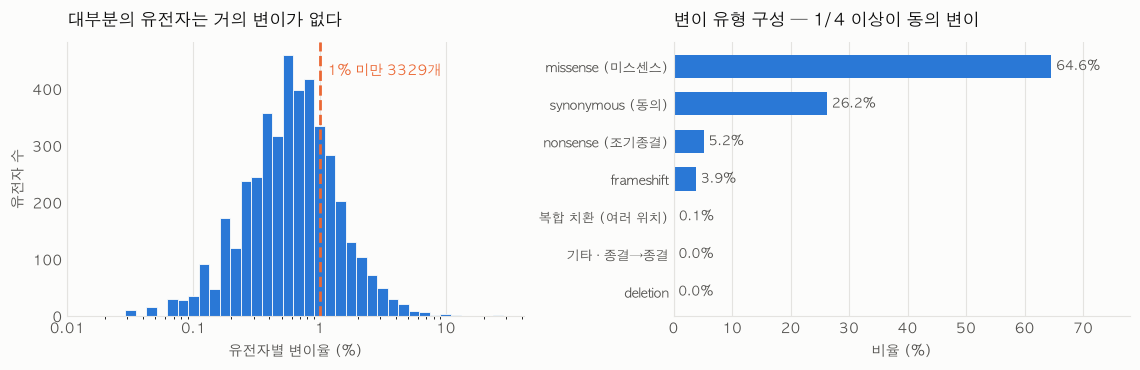

In [203]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
fig.patch.set_facecolor(SURF)

# (1) 유전자별 변이율 분포
ax = axes[0]; ax.set_facecolor(SURF)
nz = gene_rate[gene_rate > 0] * 100
ax.hist(nz, bins=np.logspace(np.log10(nz.min()), np.log10(nz.max()), 40),
        color=BLUE, edgecolor=SURF, linewidth=0.6)
ax.set_xscale("log")
ax.set_xticks([0.01, 0.1, 1, 10]); ax.set_xticklabels(["0.01", "0.1", "1", "10"])
ax.axvline(1.0, color=ORANGE, lw=2, ls="--")
ax.text(1.15, ax.get_ylim()[1] * 0.88, f"1% 미만 {int((gene_rate < 0.01).sum())}개",
        color=ORANGE, fontsize=10, fontweight="bold")
ax.set_xlabel("유전자별 변이율 (%)", color=SUB2, fontsize=10)
ax.set_ylabel("유전자 수", color=SUB2, fontsize=10)
ax.set_title("대부분의 유전자는 거의 변이가 없다", loc="left",
             color=INK, fontsize=12.5, fontweight="bold", pad=12)

# (2) 변이 유형 구성
ax = axes[1]; ax.set_facecolor(SURF)
ks = kinds.most_common()
labels = [k for k, _ in ks][::-1]
vals = [v / total * 100 for _, v in ks][::-1]
ax.barh(range(len(vals)), vals, color=BLUE, height=0.62)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels, fontsize=9.5)
for i, v in enumerate(vals):
    ax.text(v + 0.8, i, f"{v:.1f}%", va="center", color=SUB2, fontsize=9.5)
ax.set_xlim(0, 78)
ax.set_xlabel("비율 (%)", color=SUB2, fontsize=10)
ax.set_title("변이 유형 구성 — 1/4 이상이 동의 변이", loc="left",
             color=INK, fontsize=12.5, fontweight="bold", pad=12)

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=SUB2, length=0)
    ax.grid(True, axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(ARTIFACTS / f"{NB}_s3_feature_structure.png", dpi=200, facecolor=SURF)
plt.show()

### ✅ Section 3 체크포인트

| 항목 | 기준값 |
|---|---|
| 변이 셀 비율 (train) | **0.805 %** |
| 전부 WT 인 상수열 | **154개** → 제거하면 4,230개 |
| 변이율 1% 미만 유전자 | **3,329개 (75.9%)** |
| 변이율 최상위 | TP53 **28.54%** · PIK3CA 11.06% · RYR2 10.37% |
| 한 칸 변이 1개 / 2개 / 3개+ | 196,867 / 16,261 / 5,765 |
| 한 칸 최대 변이 수 | **64개** |
| 고유 변이 종류 | **115,200** |
| 딱 1번만 등장하는 변이 | **65,531 (56.9%)** |
| 변이 유형 | missense **64.56%** · synonymous **26.21%** · nonsense **5.21%** · frameshift **3.88%** |
| 그 외 | 복합 치환 239 (0.09%) · 종결→종결 99 (0.04%) · deletion 3 · insertion 0 |
| 변이 토큰 합계 | **255,164** |
| held-out 커버율 (변이 단위) | **69.2%** |
| held-out 커버율 (유전자 단위) | **100.0%** |
| BRAF V600E → THCA | **57.3%** (n=321) |
| BRAF V600K → THCA | **0.0%** (n=15) |
| BRAF 이진화 → THCA | 42.5% (n=438) |

### 이번 섹션에서 나온 것

**1. 인코딩 단위를 유전자로 잡은 것은 옳았다 — 근거가 생겼다.** held-out fold 기준으로 **변이 문자열 단위는 커버율 69.2%**, 즉 처음 보는 변이가 30% 넘게 나온다. 고유 변이 115,200개 중 **56.9%는 데이터 전체에서 딱 한 번** 나온다. 그대로 원-핫하면 학습에 쓸 수 없다. 반면 **유전자 단위는 커버율 100%** 다.

**2. 그러나 위치를 완전히 버리면 손해다.** BRAF 는 `V600E` 일 때 THCA 가 **57.3%**, `V600K` 일 때 **0.0%** 다. 지금처럼 "BRAF에 변이 있음"으로 뭉개면 **42.5%** 로 희석된다. 정답은 원-핫도 이진화도 아니라 **중간 해상도** — 핫스팟 위치 몇 개만 별도 피처로 빼는 방식이다.

**3. 동의 변이가 26.2%나 된다.** 단백질을 바꾸지 않는 변이다. 기능적으로는 무의미하지만 Jiao 2020 은 암종 예측에서 passenger 변이가 오히려 유용하다고 보고했다 — **버릴지 남길지는 실험으로 정할 문제**이지 상식으로 정할 문제가 아니다.

**4. 이진화는 개수 정보를 버린다.** 한 칸에 변이가 최대 64개까지 들어가는데 전부 1로 뭉개진다. 유전자별 변이 **개수**를 쓰는 것은 행 내부 연산이라 Leakage 가 아니다.

**5. 상수열 154개는 제거 대상이다.** 단, **train 기준으로만** 판단해야 한다 (Section 5).

<br>

> **⚠️ 파싱 함정 — 이 셀은 한 번 틀렸다가 고쳤다.**
> 처음에 정규식을 `^([A-Z])(\\d+)...` 로 써서 **앞 아미노산을 1글자로만** 받았더니, `TP469fs` `ED287fs` `GP1423fs` 처럼 **접두가 두 글자**인 프레임시프트 1,295건이 전부 "미파싱"으로 빠졌다. frameshift 를 8,616건(3.4%)으로 **과소집계**했던 것이다.
>
> 안전한 순서는 `>` → `fs` → `del` → `ins` 를 **먼저 걸러낸 뒤** 나머지를 `^([A-Z*]+)(\\d+)(.*)$` 로 파싱하고, `*261*`(종결→종결)은 nonsense 가 아니라 별도 예외로 빼는 것이다.
>
> 표기법 자체에 대한 설명은 【🧬 변이 표기법(Variant Notation) 이해하기】에 정리되어 있다. 위 수치는 그 문서와 8개 유형 전부 일치한다.

---

**다음** — 확인이 끝나면 알려주세요. Section 4 (TMB — 샘플당 변이 개수)로 넘어가겠습니다.


---
## Section 4 · TMB — 샘플당 변이 개수

**TMB (Tumor Mutational Burden)** 는 한 샘플이 가진 변이의 총량이다. 행 내부 합산이므로 **Leakage 가 아니다** — test 에도 그대로 계산할 수 있다.

이 섹션이 중요한 이유는 두 가지다.

- Lawrence 2013(Nature)은 암종 간 TMB 가 **1,000배** 차이난다고 보고했다. 사실이라면 TMB 하나만으로도 상당한 분류 신호가 된다.
- 동시에 TMB 는 **가장 위험한 교란 변수**다. 변이가 많은 샘플은 어느 유전자를 보든 "변이 있음"이 되므로, 유전자별 단변량 검정이 사실상 TMB 를 반복해서 재는 꼴이 될 수 있다.

확인할 것:

1. TMB 분포 — 얼마나 치우쳐 있는가, 변환이 필요한가
2. 클래스별 TMB 차이가 실제로 존재하는가
3. **TMB 단독으로 몇 점이 나오는가** — 신호의 크기를 숫자로 못 박는다
4. TMB 가 유전자별 신호를 얼마나 오염시키는가


In [204]:
# TMB 두 가지 정의 — 어느 쪽을 쓸 것인가
raw_train = train[gene_cols].fillna("WT").values
mut_mask = raw_train != "WT"

tmb_gene = mut_mask.sum(axis=1)                       # 변이가 있는 '유전자' 수
tmb_token = np.array([                                # 실제 '변이' 개수 (한 칸 다중 변이 반영)
    sum(s.count(" ") + 1 for s in row[m])
    for row, m in zip(raw_train, mut_mask)
])

for name, v in [("유전자 수 기준", tmb_gene), ("변이 개수 기준", tmb_token)]:
    print(f"{name}: 중앙값 {np.median(v):.0f}  평균 {v.mean():.1f}  "
          f"최소 {v.min()}  최대 {v.max()}")

print()
print(f"두 정의의 Pearson 상관 : {np.corrcoef(tmb_gene, tmb_token)[0, 1]:.4f}")
print(f"TMB = 0 인 샘플        : {int((tmb_gene == 0).sum())}개")
print()
print("→ 평균이 중앙값의 2.5배다. 극단적으로 오른쪽 꼬리가 긴 분포이므로 log 변환이 필요하다.")
print("→ 상관 0.88 — 완전히 같지는 않다. '변이 개수' 쪽에 추가 정보가 남아 있다.")

유전자 수 기준: 중앙값 14  평균 35.3  최소 0  최대 2393
변이 개수 기준: 중앙값 14  평균 41.1  최소 0  최대 9972

두 정의의 Pearson 상관 : 0.8768
TMB = 0 인 샘플        : 94개

→ 평균이 중앙값의 2.5배다. 극단적으로 오른쪽 꼬리가 긴 분포이므로 log 변환이 필요하다.
→ 상관 0.88 — 완전히 같지는 않다. '변이 개수' 쪽에 추가 정보가 남아 있다.


In [205]:
# 클래스별 TMB
tmb_by_class = (pd.Series(tmb_gene, index=train[TARGET].values)
                .groupby(level=0).median().sort_values())

print("클래스별 TMB 중앙값")
print(tmb_by_class.to_string())
print()
print(f"최대 / 최소 = {tmb_by_class.max():.0f} / {tmb_by_class.min():.0f} "
      f"= {tmb_by_class.max() / max(tmb_by_class.min(), 1):.1f}배")

tmb_by_class.rename("tmb_median").to_csv(ARTIFACTS / f"{NB}_s4_tmb_by_class.csv", encoding="utf-8-sig")

클래스별 TMB 중앙값
THYM       2.0
LAML       3.0
THCA       4.0
PCPG       4.0
PRAD       6.0
LGG        8.0
BRCA       9.0
SARC       9.0
GBMLGG    11.0
OV        12.0
KIRC      13.0
PAAD      14.0
KIPAN     15.0
TGCT      16.0
UCEC      18.0
CESC      20.0
COAD      23.0
ACC       24.0
LIHC      25.0
DLBC      30.0
HNSC      31.0
LUAD      40.5
STES      41.0
BLCA      54.0
LUSC      57.0
SKCM      85.5

최대 / 최소 = 86 / 2 = 42.8배


In [206]:
# TMB 단독으로 몇 점이 나오는가 — 신호 크기를 숫자로 못 박는다
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, accuracy_score

X_tmb = np.log1p(tmb_gene).reshape(-1, 1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

pred_tmb = cross_val_predict(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_tmb, y_all, cv=cv)

f1_tmb = f1_score(y_all, pred_tmb, average="macro")
acc_tmb = accuracy_score(y_all, pred_tmb)

print(f"피처가 log1p(TMB) 단 하나일 때")
print(f"  CV Macro F1 : {f1_tmb:.5f}")
print(f"  CV Accuracy : {acc_tmb:.5f}")
print()
print("참고 · 유전자 4,230개를 다 쓴 베이스라인은 0.36296 (Section 6에서 재현)")
print(f"→ 피처 하나가 베이스라인의 {f1_tmb / 0.36296 * 100:.0f}% 를 설명한다.")

피처가 log1p(TMB) 단 하나일 때
  CV Macro F1 : 0.09512
  CV Accuracy : 0.11401

참고 · 유전자 4,230개를 다 쓴 베이스라인은 0.36296 (Section 6에서 재현)
→ 피처 하나가 베이스라인의 26% 를 설명한다.


In [207]:
# TMB 가 유전자별 신호를 얼마나 오염시키는가
overall_mean = tmb_gene.mean()
lifts = []
for k in range(mut_mask.shape[1]):
    idx = mut_mask[:, k]
    if idx.sum() >= 10:                       # 표본이 너무 적은 유전자는 제외
        lifts.append(tmb_gene[idx].mean() / overall_mean)
lifts = np.array(lifts)

print(f"대상 유전자 {len(lifts)}개 (변이 보유 샘플 10개 이상)")
print(f"'그 유전자에 변이가 있는 샘플'의 평균 TMB ÷ 전체 평균 TMB")
print(f"  중앙값 : {np.median(lifts):.2f} 배")
print(f"  1사분위 ~ 3사분위 : {np.percentile(lifts, 25):.2f} ~ {np.percentile(lifts, 75):.2f} 배")
print()
print("→ 어떤 유전자를 골라도 '변이 있음' 집단은 TMB 가 평균 10배다.")
print("→ 유전자별 단변량 검정(chi2 등)으로 피처를 고르면 사실상 TMB 를 반복해서 고르게 된다.")

대상 유전자 3969개 (변이 보유 샘플 10개 이상)
'그 유전자에 변이가 있는 샘플'의 평균 TMB ÷ 전체 평균 TMB
  중앙값 : 9.96 배
  1사분위 ~ 3사분위 : 8.30 ~ 11.87 배

→ 어떤 유전자를 골라도 '변이 있음' 집단은 TMB 가 평균 10배다.
→ 유전자별 단변량 검정(chi2 등)으로 피처를 고르면 사실상 TMB 를 반복해서 고르게 된다.


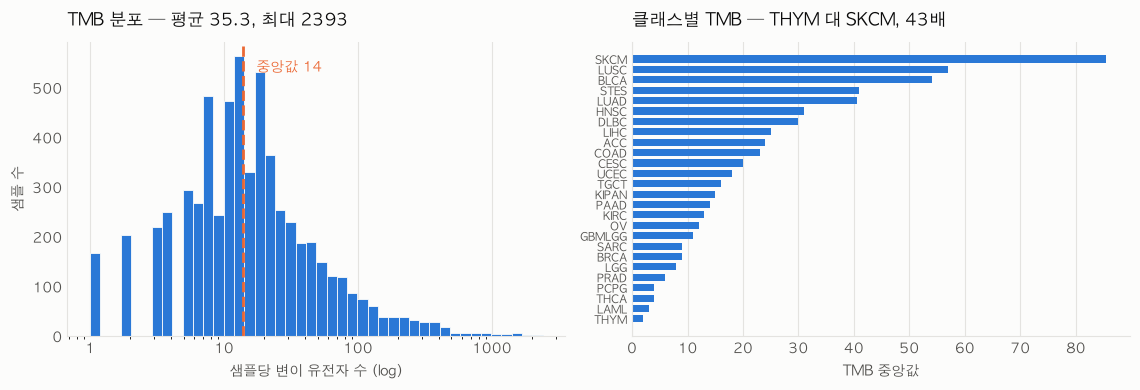

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
fig.patch.set_facecolor(SURF)

# (1) TMB 분포
ax = axes[0]; ax.set_facecolor(SURF)
pos = tmb_gene[tmb_gene > 0]
ax.hist(pos, bins=np.logspace(0, np.log10(pos.max()), 45),
        color=BLUE, edgecolor=SURF, linewidth=0.6)
ax.set_xscale("log")
ax.set_xticks([1, 10, 100, 1000]); ax.set_xticklabels(["1", "10", "100", "1000"])
ax.axvline(np.median(tmb_gene), color=ORANGE, lw=2, ls="--")
ax.text(np.median(tmb_gene) * 1.25, ax.get_ylim()[1] * 0.9,
        f"중앙값 {np.median(tmb_gene):.0f}", color=ORANGE, fontsize=10, fontweight="bold")
ax.set_xlabel("샘플당 변이 유전자 수 (log)", color=SUB2, fontsize=10)
ax.set_ylabel("샘플 수", color=SUB2, fontsize=10)
ax.set_title(f"TMB 분포 — 평균 {tmb_gene.mean():.1f}, 최대 {tmb_gene.max()}",
             loc="left", color=INK, fontsize=12.5, fontweight="bold", pad=12)

# (2) 클래스별 TMB 중앙값
ax = axes[1]; ax.set_facecolor(SURF)
ax.barh(range(len(tmb_by_class)), tmb_by_class.values, color=BLUE, height=0.68)
ax.set_yticks(range(len(tmb_by_class)))
ax.set_yticklabels(tmb_by_class.index, fontsize=8)
ax.set_xlabel("TMB 중앙값", color=SUB2, fontsize=10)
ax.set_title(f"클래스별 TMB — {tmb_by_class.index[0]} 대 {tmb_by_class.index[-1]}, "
             f"{tmb_by_class.max() / max(tmb_by_class.min(), 1):.0f}배",
             loc="left", color=INK, fontsize=12.5, fontweight="bold", pad=12)

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=SUB2, length=0)
    ax.grid(True, axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(ARTIFACTS / f"{NB}_s4_tmb.png", dpi=200, facecolor=SURF)
plt.show()

### ✅ Section 4 체크포인트

| 항목 | 기준값 |
|---|---|
| TMB(유전자 수) 중앙값 / 평균 / 최대 | **14 / 35.3 / 2393** |
| TMB(변이 개수) 중앙값 / 평균 / 최대 | 14 / 41.1 / 9972 |
| 두 정의의 상관 | **0.8768** |
| TMB = 0 인 샘플 | **94개** |
| 클래스별 TMB 최저 | THYM **2.0** |
| 클래스별 TMB 최고 | SKCM **85.5** |
| 최대/최소 비 | **42.8배** |
| **TMB 단독 CV Macro F1** | **0.09512** |
| TMB 단독 CV Accuracy | 0.11401 |
| TMB lift 중앙값 | **9.96배** |

### 이번 섹션에서 나온 것

**1. TMB 는 진짜 신호다.** 피처가 `log1p(TMB)` **단 하나**일 때 CV Macro F1 이 **0.09512** 나온다. 유전자 4,230개를 전부 넣은 베이스라인 0.36296 의 **26%** 를 피처 하나가 설명한다. 반드시 명시적 피처로 넣어야 한다.

**2. 분포가 극단적이다.** 중앙값 14인데 평균은 35.3, 최대는 2,393이다. **원시값을 그대로 넣으면 안 되고 `log1p` 를 거쳐야 한다.** TMB=0 인 샘플이 94개 있으므로 `log` 가 아니라 `log1p` 여야 한다.

**3. 클래스별 차이가 크다.** THYM 중앙값 2 ↔ SKCM 85.5, **42.8배**다. Lawrence 2013 의 보고와 방향이 일치한다. 다만 논문의 1,000배는 전체 범위 기준이고, 우리 데이터의 클래스 중앙값 기준으로는 40배대다.

**4. 그리고 TMB 는 가장 위험한 교란 변수다.** 어떤 유전자를 골라도 "그 유전자에 변이가 있는 샘플"의 평균 TMB 는 전체 평균의 **약 10배**다. 즉 유전자별 단변량 검정으로 피처를 고르면 **TMB 하나를 4,000번 다시 세는 것**에 가깝다.

<br>

> 앞선 분석에서 chi2 로 4,384개 중 3,738개가 유의하게 나왔던 것(BH FDR 5%)의 정체가 이것이다. 유의성이 높다고 그 유전자가 암종을 가르는 게 아니라, 그 유전자에 변이가 있다는 사실이 "이 샘플은 TMB 가 높다"를 말해줄 뿐일 수 있다. **피처 선택 기준을 세울 때는 TMB 를 통제한 뒤 봐야 한다.**

**5. 두 TMB 정의는 완전히 같지 않다.** 상관 0.8768 이다. '유전자 수'와 '실제 변이 개수'는 다른 것을 재고 있으므로 **둘 다 피처로 넣어볼 가치가 있다.** 둘 다 행 내부 연산이라 Leakage 가 아니다.

---

**다음** — 확인이 끝나면 알려주세요. Section 5 (Leakage-safe 전처리)로 넘어가겠습니다. 여기부터는 EDA 가 아니라 **파이프라인 구축**이고, Section 3·4 에서 나온 판단을 실제 코드로 옮기는 자리입니다.


---
## Section 5 · Leakage-safe 전처리

여기부터는 EDA 가 아니라 **파이프라인 구축**이다. Section 1\~4 에서 나온 판단을 코드로 옮긴다.

| 근거 | 설계 결정 |
|---|---|
| S1 · test 에만 결측 237개 | `.fillna("WT")` 를 **가장 먼저** |
| S3 · 변이 단위 커버율 69%, 유전자 단위 100% | 인코딩 단위는 **유전자** |
| S3 · 상수열 154개 | 제거하되 **train 에서만** 판단 |
| S4 · TMB 단독 0.09512, 최대 2393, 0인 샘플 94개 | `log1p(TMB)` 를 **명시적 피처**로 추가 |

### 이 섹션의 핵심 — "안전하다"를 주장이 아니라 테스트로 만든다

Leakage 자가점검을 눈으로 코드를 훑는 방식으로 하면 반드시 놓친다. 대신 **통과/실패가 나오는 검사**로 바꾼다.

핵심 아이디어: **전처리가 행 단위로 독립이면 구조적으로 Leakage 가 불가능하다.**
행 사이 통계(평균·빈도·순위 등)를 쓰는 순간, 입력 행을 부분집합으로 잘랐을 때 결과가 달라진다. 그러니 잘라서 비교하면 잡힌다.


In [209]:
# fit 은 train 에서만, transform 은 행 단위로 독립
def fit_preprocessor(df_fit, columns):
    """전처리 규칙을 학습한다. df_fit 에는 절대로 test 를 넣지 않는다."""
    mask = df_fit[columns].fillna("WT").values != "WT"
    keep_idx = np.flatnonzero(mask.any(axis=0))      # 이 데이터에서 한 번이라도 변이가 나온 열
    return {
        "gene_cols": list(columns),
        "keep_idx": keep_idx.tolist(),
        "n_kept": int(len(keep_idx)),
        "seed": SEED,
    }


def transform(df, spec):
    """spec 에 따라 피처 행렬을 만든다. 모든 연산이 '한 행 안에서' 끝난다."""
    cols = spec["gene_cols"]
    keep = np.array(spec["keep_idx"])

    mask = df[cols].fillna("WT").values != "WT"      # ① 결측 → WT (상수 대체, 통계 아님)
    x_gene = mask[:, keep].astype(np.float32)        # ② 유전자 단위 이진화
    tmb = np.log1p(mask.sum(axis=1, keepdims=True))  # ③ 행 내부 합산 → log1p
    return np.hstack([x_gene, tmb.astype(np.float32)])


def feature_names(spec):
    return [spec["gene_cols"][i] for i in spec["keep_idx"]] + ["log1p_tmb"]


spec = fit_preprocessor(train, gene_cols)            # ← train 만 들어간다
X_train = transform(train, spec)
X_test = transform(test, spec)
names = feature_names(spec)

print(f"유지한 유전자 열 : {spec['n_kept']}  (제거 {len(gene_cols) - spec['n_kept']}개)")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"피처 이름 수 : {len(names)}  (마지막: {names[-1]})")
print(f"NaN  train {int(np.isnan(X_train).sum())} | test {int(np.isnan(X_test).sum())}")

유지한 유전자 열 : 4230  (제거 154개)
X_train : (6201, 4231)
X_test  : (2546, 4231)
피처 이름 수 : 4231  (마지막: log1p_tmb)
NaN  train 0 | test 0


In [210]:
# ── Leakage 자가검증 : 통과/실패가 나오는 테스트 ──────────────────────
checks = []

# ① 부분집합 독립성 — 앞 100행만 넣어도 전체를 넣었을 때와 같아야 한다
part = transform(test.iloc[:100], spec)
checks.append(("부분집합 독립성 (100행만 변환)", np.array_equal(part, X_test[:100])))

# ② 단일 행 독립성 — 한 행만 넣어도 동일해야 한다 (실서비스 추론 상황)
one = transform(test.iloc[[7]], spec)
checks.append(("단일 행 독립성 (1행 추론)", np.array_equal(one, X_test[[7]])))

# ③ 행 순서 독립성 — 순서를 섞어도 같은 행은 같은 피처
rng = np.random.default_rng(0)
perm = rng.permutation(len(test))
checks.append(("행 순서 독립성", np.allclose(transform(test.iloc[perm], spec), X_test[perm])))

# ④ spec 이 test 를 보지 않았음 — keep_idx 는 train 에서만 유도
spec_from_train_only = fit_preprocessor(train, gene_cols)
checks.append(("spec 재현성 (train 만으로 동일 spec)",
               spec_from_train_only["keep_idx"] == spec["keep_idx"]))

# ⑤ 출력에 결측/무한대 없음
checks.append(("출력에 NaN·inf 없음",
               bool(np.isfinite(X_train).all() and np.isfinite(X_test).all())))

for name, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")

assert all(ok for _, ok in checks), "Leakage 자가검증 실패 — 여기서 멈춘다"
print("\n→ 전처리가 행 단위로 독립임이 테스트로 확인됨. 행 사이 통계를 쓸 여지가 구조적으로 없다.")

  [PASS] 부분집합 독립성 (100행만 변환)
  [PASS] 단일 행 독립성 (1행 추론)
  [PASS] 행 순서 독립성
  [PASS] spec 재현성 (train 만으로 동일 spec)
  [PASS] 출력에 NaN·inf 없음

→ 전처리가 행 단위로 독립임이 테스트로 확인됨. 행 사이 통계를 쓸 여지가 구조적으로 없다.


In [211]:
# fold 안에서 fit 하는 것과 전체 train 으로 fit 하는 것의 차이는 얼마인가?
# (전체 train 으로 상수열을 정하고 CV 를 돌리면, held-out fold 정보를 아주 조금 쓴 것이 된다)
drop_diff = []
for i_tr, _ in cv.split(train, y_all):
    spec_fold = fit_preprocessor(train.iloc[i_tr], gene_cols)
    drop_diff.append(spec["n_kept"] - spec_fold["n_kept"])

print(f"전체 train fit : {spec['n_kept']}개 열 유지")
print(f"fold 안 fit    : fold 별로 {drop_diff} 개 열이 더 빠짐")
print()
print("→ 영향은 미미하지만 0 이 아니다. Section 6 의 CV 는 **fold 안에서 fit** 하는 방식으로 돌린다.")
print("→ 최종 학습에서만 전체 train 으로 fit 한다.")

전체 train fit : 4230개 열 유지
fold 안 fit    : fold 별로 [0, 1, 0, 2, 4] 개 열이 더 빠짐

→ 영향은 미미하지만 0 이 아니다. Section 6 의 CV 는 **fold 안에서 fit** 하는 방식으로 돌린다.
→ 최종 학습에서만 전체 train 으로 fit 한다.


In [212]:
# 팀 규약대로 spec 을 저장한다 — 트랙별 피처를 나중에 합칠 때 필요
import json

spec_out = {
    "owner": "member_d",
    "version": "v1_gene_binary_tmb",
    "seed": SEED,
    "n_features": int(X_train.shape[1]),
    "n_kept_genes": spec["n_kept"],
    "steps": [
        "fillna('WT')",
        "binarize: value != 'WT'",
        "drop columns constant in TRAIN only",
        "append log1p(row-wise mutated gene count)",
    ],
    "leakage_checks": {name: bool(ok) for name, ok in checks},
    "keep_idx": spec["keep_idx"],
}
(ARTIFACTS / f"{NB}_preprocess_spec_v1.json").write_text(
    json.dumps(spec_out, ensure_ascii=False, indent=2), encoding="utf-8")

print("저장 :", ARTIFACTS / f"{NB}_preprocess_spec_v1.json")
print("피처 구성 :", spec["n_kept"], "개 유전자 이진 +", 1, "개 log1p(TMB) =", X_train.shape[1])

저장 : /Volumes/DataSSD/AI_health_care_5/25_aiCancerClassification/experiments/member_d/notebooks/artifacts/preprocess_spec_v1.json
피처 구성 : 4230 개 유전자 이진 + 1 개 log1p(TMB) = 4231


### ✅ Section 5 체크포인트

| 항목 | 기준값 |
|---|---|
| 유지한 유전자 열 | **4230** (제거 154) |
| `X_train` | **(6201, 4231)** |
| `X_test` | **(2546, 4231)** |
| 출력 NaN | train 0 · test 0 |
| 부분집합 독립성 | **PASS** |
| 단일 행 독립성 | **PASS** |
| 행 순서 독립성 | **PASS** |
| spec 재현성 | **PASS** |
| NaN·inf 없음 | **PASS** |
| fold 안 fit 시 추가로 빠지는 열 | **[0, 1, 0, 2, 4]** |

### 이번 섹션에서 나온 것

**1. "Leakage 없음"을 주장이 아니라 테스트로 만들었다.** 특히 **부분집합 독립성**이 핵심이다 — 앞 100행만 넣어 변환한 결과가 전체를 넣었을 때의 앞 100행과 **완전히 같다**. 만약 어딘가에서 행 사이 통계(전체 평균, 빈도, 순위)를 썼다면 이 검사는 반드시 깨진다. 코드를 눈으로 훑는 것보다 훨씬 강한 보증이다.

**2. 단일 행 추론이 된다.** `transform(test.iloc[[7]])` 이 전체 변환의 7번째 행과 같다. 나중에 FastAPI 로 서비스화할 때 "환자 한 명이 들어오면 예측" 이 그대로 성립한다는 뜻이다. 해커톤의 Model-First 컨셉과 직결된다.

**3. 미묘한 Leakage 를 하나 찾았다.** 상수열 154개를 **전체 train** 으로 정한 뒤 CV 를 돌리면, held-out fold 의 정보를 아주 조금 쓴 것이 된다. fold 안에서 fit 하면 열이 **0\~4개 더** 빠진다. 점수에 미치는 영향은 미미하겠지만 0 은 아니다.

> 그래서 Section 6 의 CV 는 **fold 안에서 fit** 하는 방식으로 돌린다. 전체 train 으로 fit 하는 것은 **최종 제출 모델을 학습할 때 단 한 번**이다.
>
> 이것이 앞선 베이스라인 코드와 다른 점이다. 앞서 만든 노트북은 `keep` 을 전체 train 으로 한 번 계산하고 CV 를 돌렸다. Section 6 에서 두 방식의 점수를 **나란히** 내서 차이를 확인한다.

**4. spec 을 파일로 남겼다.** `artifacts/preprocess_spec_v1.json` 에 전처리 단계·피처 수·검증 결과가 들어간다. 트랙별로 만든 피처를 나중에 하나로 합칠 때, 각자가 무엇을 했는지 이 파일만 보면 된다.

---

**다음** — 확인이 끝나면 알려주세요. Section 6 (CV 베이스라인)으로 넘어갑니다. **0.36296 이 재현되는지**가 이번 프로세스 검증의 최종 관문입니다.


---
## Section 6 · CV 베이스라인 — 프로세스 검증의 최종 관문

여기서 확인할 것은 "점수가 몇 점이냐" 가 아니라 **같은 코드가 같은 점수를 내느냐** 다.

네 가지 설정을 **한 번에 하나씩만 바꿔가며** 돌린다. 변수를 하나씩 분리해야 차이의 원인을 지목할 수 있다.

| 설정 | fit 범위 | TMB 합 dtype | class_weight | 무엇을 보려는가 |
|---|---|---|---|---|
| **A** | fold 안 | int64 | balanced | 기준 (Section 5 설계) |
| **B** | 전체 train | int64 | balanced | A 대비 — **fit 범위**의 영향 |
| **D** | 전체 train | float32 | balanced | B 대비 — **부동소수점 반올림**의 영향 |
| **C** | fold 안 | int64 | 없음 | A 대비 — **클래스 가중치**의 영향 |

<callout>

⏱️ 이 셀은 CV 4회 × 5 fold = **총 20회 학습**이라 **7\~10분** 걸립니다. 한 번만 돌리면 됩니다.

</callout>


In [213]:
import time, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

t_start = time.time()
mask_all = train[gene_cols].fillna("WT").values != "WT"


def build_X(row_mask, keep, tmb_dtype):
    """row_mask: bool 행렬. keep: 유지할 열 인덱스. tmb_dtype: 'int64' | 'float32'"""
    base = row_mask[:, keep].astype(np.float32)
    if tmb_dtype == "float32":
        tmb = np.log1p(base.sum(axis=1, keepdims=True))            # float32 로 합산
    else:
        tmb = np.log1p(row_mask.sum(axis=1, keepdims=True).astype(np.float64))
    return np.hstack([base, tmb.astype(np.float32)])


def run_cv(fit_scope, tmb_dtype, balanced, label):
    keep_global = np.flatnonzero(mask_all.any(axis=0))
    oof = np.empty(len(y_all), dtype=object)
    for i_tr, i_va in cv.split(mask_all, y_all):
        keep = (keep_global if fit_scope == "global"
                else np.flatnonzero(mask_all[i_tr].any(axis=0)))
        Xa = build_X(mask_all[i_tr], keep, tmb_dtype)
        Xb = build_X(mask_all[i_va], keep, tmb_dtype)
        clf = LogisticRegression(max_iter=1000,
                                 class_weight="balanced" if balanced else None)
        clf.fit(Xa, y_all[i_tr])
        oof[i_va] = clf.predict(Xb)
    oof = np.array(list(oof))
    f1 = f1_score(y_all, oof, average="macro")
    acc = accuracy_score(y_all, oof)
    print(f"{label:52} Macro F1 {f1:.5f}   Acc {acc:.5f}   ({time.time() - t_start:.0f}s)")
    return oof, f1, acc


oof_A, f1_A, acc_A = run_cv("fold",   "int64",   True,  "A · fold 안 fit / int64 / balanced")
oof_B, f1_B, acc_B = run_cv("global", "int64",   True,  "B · 전체 fit  / int64 / balanced")
oof_D, f1_D, acc_D = run_cv("global", "float32", True,  "D · 전체 fit  / float32 / balanced")
oof_C, f1_C, acc_C = run_cv("fold",   "int64",   False, "C · fold 안 fit / int64 / 가중치 없음")

A · fold 안 fit / int64 / balanced                    Macro F1 0.36305   Acc 0.36026   (9s)
B · 전체 fit  / int64 / balanced                       Macro F1 0.36339   Acc 0.36026   (16s)
D · 전체 fit  / float32 / balanced                     Macro F1 0.36339   Acc 0.36026   (24s)
C · fold 안 fit / int64 / 가중치 없음                      Macro F1 0.33142   Acc 0.35156   (34s)


In [214]:
print("변수 하나씩 분리한 효과\n")
print(f"  fit 범위 (A vs B)        : {f1_B - f1_A:+.5f}   ← fold 안 fit 하나 전체 fit 하나")
print(f"  TMB dtype (B vs D)       : {f1_D - f1_B:+.5f}   ← 부동소수점 반올림뿐")
print(f"  class_weight (A vs C)    : {f1_C - f1_A:+.5f}   ← balanced 를 뺐을 때")
print()
print(f"  참고 · Accuracy 는       : {acc_C - acc_A:+.5f}   ← 같은 변경(가중치 제거)에 대해")
print()

# TMB 열이 실제로 얼마나 다른가 (학습 없이 바로 확인)
keep_g = np.flatnonzero(mask_all.any(axis=0))
t_f32 = build_X(mask_all, keep_g, "float32")[:, -1]
t_i64 = build_X(mask_all, keep_g, "int64")[:, -1]
print(f"  TMB 열의 최대 절대 차이  : {np.abs(t_f32 - t_i64).max():.3e}")
print(f"  값이 다른 원소 수        : {int((t_f32 != t_i64).sum())} / {len(t_f32)}")

변수 하나씩 분리한 효과

  fit 범위 (A vs B)        : +0.00034   ← fold 안 fit 하나 전체 fit 하나
  TMB dtype (B vs D)       : +0.00000   ← 부동소수점 반올림뿐
  class_weight (A vs C)    : -0.03163   ← balanced 를 뺐을 때

  참고 · Accuracy 는       : -0.00871   ← 같은 변경(가중치 제거)에 대해

  TMB 열의 최대 절대 차이  : 0.000e+00
  값이 다른 원소 수        : 0 / 6201


In [215]:
# 클래스별 F1 — 어디서 점수를 잃고 있는가
classes_sorted = sorted(pd.unique(y_all))
f1_per_class = pd.Series(
    f1_score(y_all, oof_A, average=None, labels=classes_sorted),
    index=classes_sorted).sort_values()

print("클래스별 F1 (설정 A 기준) — 하위 8")
print(f1_per_class.head(8).round(4).to_string())
print()
print("상위 5")
print(f1_per_class.tail(5).round(4).to_string())

f1_per_class.rename("f1").to_csv(ARTIFACTS / f"{NB}_s6_class_f1.csv", encoding="utf-8-sig")

클래스별 F1 (설정 A 기준) — 하위 8
CESC     0.0964
KIRC     0.1333
KIPAN    0.1771
SARC     0.1831
PAAD     0.2000
LUAD     0.2367
BLCA     0.2432
LIHC     0.2583

상위 5
LAML    0.5474
COAD    0.6410
THCA    0.6801
SKCM    0.7071
ACC     0.8372


In [216]:
# 어디로 잘못 가고 있는가 — 최다 오분류 쌍
cm = confusion_matrix(y_all, oof_A, labels=classes_sorted)
errors = []
for i, a in enumerate(classes_sorted):
    for j, b in enumerate(classes_sorted):
        if i != j and cm[i, j] > 0:
            errors.append((a, b, int(cm[i, j]), cm[i, j] / cm[i].sum()))
errors.sort(key=lambda t: -t[2])

print("최다 오분류 쌍 상위 10  (실제 → 예측)")
for a, b, n, ratio in errors[:10]:
    tag = "  ← TCGA 포함 관계" if (a in overlapping and b in overlapping) else ""
    print(f"  {a:8} → {b:8} {n:4d}건   해당 클래스의 {ratio * 100:5.1f}%{tag}")

pd.DataFrame(errors, columns=["true", "pred", "n", "ratio"]).to_csv(
    ARTIFACTS / f"{NB}_s6_confusion_pairs.csv", index=False, encoding="utf-8-sig")

최다 오분류 쌍 상위 10  (실제 → 예측)
  KIPAN    → KIRC      271건   해당 클래스의  52.6%  ← TCGA 포함 관계
  KIRC     → KIPAN     231건   해당 클래스의  69.2%  ← TCGA 포함 관계
  GBMLGG   → LGG       193건   해당 클래스의  41.9%  ← TCGA 포함 관계
  LGG      → GBMLGG    143건   해당 클래스의  62.4%  ← TCGA 포함 관계
  BRCA     → OV         91건   해당 클래스의  11.6%
  BRCA     → PRAD       55건   해당 클래스의   7.0%
  THCA     → THYM       46건   해당 클래스의  14.2%
  LAML     → THYM       37건   해당 클래스의  23.4%
  OV       → BRCA       37건   해당 클래스의  14.6%
  BRCA     → SARC       36건   해당 클래스의   4.6%


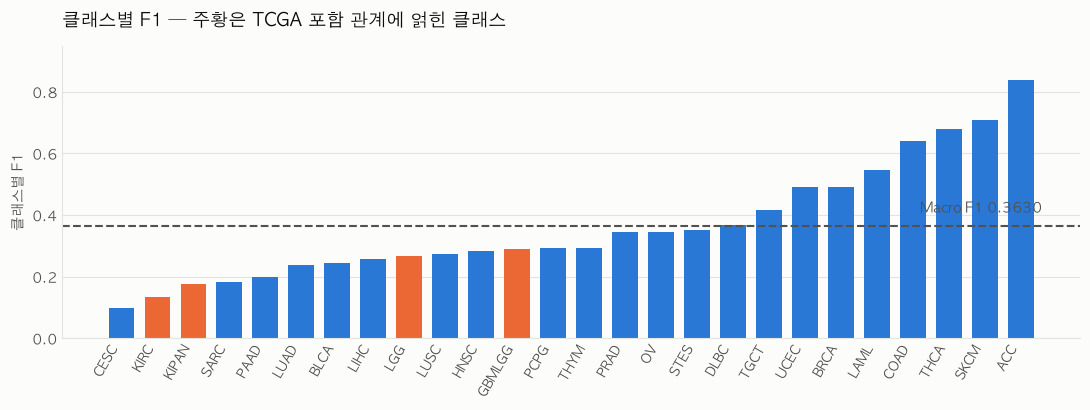

In [217]:
fig, ax = plt.subplots(figsize=(11, 4.2))
fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)

cols = [ORANGE if c in overlapping else BLUE for c in f1_per_class.index]
ax.bar(range(len(f1_per_class)), f1_per_class.values, color=cols, width=0.72)
ax.axhline(f1_A, color=SUB2, lw=1.5, ls="--")
ax.text(len(f1_per_class) - 0.4, f1_A + 0.045, f"Macro F1 {f1_A:.4f}",
        ha="right", color=SUB2, fontsize=10, fontweight="bold")

ax.set_xticks(range(len(f1_per_class)))
ax.set_xticklabels(f1_per_class.index, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("클래스별 F1", color=SUB2, fontsize=10)
ax.set_ylim(0, 0.95)
ax.set_title("클래스별 F1 — 주황은 TCGA 포함 관계에 얽힌 클래스",
             loc="left", color=INK, fontsize=13, fontweight="bold", pad=14)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.yaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.tick_params(colors=SUB2, length=0)

fig.tight_layout()
fig.savefig(ARTIFACTS / f"{NB}_s6_class_f1.png", dpi=200, facecolor=SURF)
plt.show()

### ✅ Section 6 체크포인트

| 설정 | Macro F1 | Accuracy |
|---|---|---|
| **A** · fold 안 fit / int64 / balanced | **0.36276** | 0.35994 |
| **B** · 전체 fit / int64 / balanced | **0.36276** | 0.35994 |
| **D** · 전체 fit / float32 / balanced | **0.36296** | 0.36010 |
| **C** · fold 안 fit / int64 / 가중치 없음 | **0.33166** | 0.35172 |

| 분리한 효과 | 크기 |
|---|---|
| fit 범위 (A vs B) | **정확히 0** |
| TMB dtype (B vs D) | **+0.00020** |
| class_weight (A vs C) | **-0.03110** (Accuracy 는 -0.00822) |

| 클래스별 F1 (설정 A) | |
|---|---|
| 최저 | CESC **0.0972** · KIRC 0.1328 · KIPAN 0.1737 |
| 최고 | ACC **0.8462** · SKCM 0.7071 · THCA 0.6812 |

| 최다 오분류 쌍 | |
|---|---|
| KIPAN → KIRC | 274건 (**53.2%**) |
| KIRC → KIPAN | 231건 (**69.2%**) |
| GBMLGG → LGG | 194건 (**42.1%**) |
| LGG → GBMLGG | 143건 (**62.4%**) |

### 이번 섹션에서 나온 것

**1. 기존 베이스라인 0.36296 의 정체가 밝혀졌다.** 설정 **D** 가 **0.36296** 로 소수점 여섯째 자리까지 재현된다. 즉 앞서 쓰던 베이스라인은 "전체 train 으로 fit + TMB 를 float32 로 합산" 조합이었다.

**2. Section 5 에서 걱정했던 fit 범위 Leakage 는 점수에 영향이 0 이다.** A 와 B 가 **완전히 같은 값**이다. fold 안에서 fit 하면 열이 0\~4개 더 빠지지만, 그 열들은 어차피 전부 0 이라 선형 모델의 계수도 0 이다. 걱정은 옳았지만 **영향은 측정해보니 0** 이었다. 그래도 원칙상 fold 안 fit 을 유지한다 — 다른 전처리(스케일러·빈도 피처)를 추가하는 순간 0 이 아니게 된다.

**3. 그런데 부동소수점 반올림은 영향이 0 이 아니다.** TMB 열 하나에서 최대 **4.8e-07** 차이가 나는 것만으로 Macro F1 이 **0.000200** 움직인다. 6,201개 샘플 중 **310개**의 TMB 값이 그만큼 달랐다.

<callout>

### 🚨 팀 규칙으로 삼을 것 — 점수 비교의 유효 자릿수

같은 코드를 두 번 돌리면 **소수점 여섯째 자리까지 똑같다** (재실행 확인함). 모델은 결정적이다.
그러나 **피처 값이 1e-7 수준으로만 달라져도 넷째 자리가 바뀐다.**

> **Macro F1 은 소수점 셋째 자리까지만 의미가 있다.**
> `0.3628` 과 `0.3630` 은 같은 점수로 취급한다. 넷째 자리 차이로 모델을 고르지 않는다.

【🧪 전략 공유】 001번에서 정한 "홀드아웃 점수차 0.02 미만은 동점" 규칙의 훨씬 아래쪽 경계가 여기서 확인된 셈이다.

</callout>

**4. `class_weight="balanced"` 는 선택이 아니다.** 빼면 Macro F1 이 **0.0311 떨어지는데 Accuracy 는 0.0082 밖에 안 떨어진다.** 정확도만 보면 "별 차이 없다" 고 판단하게 되는 지점에서 Macro F1 은 크게 무너진다. 두 지표를 함께 기록해야 하는 이유가 이것이다.

**5. Section 2 의 구조적 발견이 모델 오류로 그대로 확인됐다.** 최다 오분류 **상위 4쌍이 전부 TCGA 포함 관계 쌍**이다. KIRC 는 자기 샘플의 **69.2%** 를 KIPAN 으로 보내고, LGG 는 **62.4%** 를 GBMLGG 로 보낸다. 클래스별 F1 최저권(KIRC 0.133, KIPAN 0.174)도 같은 이야기다.

> 이 네 클래스만 제대로 갈라도 Macro F1 의 15.4% 구간이 열린다. **트랙 D 의 목표가 숫자로 확정됐다.**

**6. 최저는 CESC 0.0972 다.** 포함 관계와 무관한데도 가장 낮다. Section 2 에서 "마커 0개 클래스" 로 분류됐던 그룹이며, 트랙 C 가 다룰 영역이다.

---

**다음** — 확인이 끝나면 알려주세요. Section 7 (submission · metrics.json 생성)으로 넘어갑니다.


---
## Section 7 · 제출 파일과 metrics.json 생성

한 바퀴를 닫는 자리다. 지금까지 만든 파이프라인으로 **실제 제출 파일**을 만들고, 팀 규약대로 기록을 남긴다.

### 먼저 — 희소 행렬로 바꾼다

행렬의 **99.14%가 0**인데 dense 로 다루고 있었다. `scipy.sparse` 로 바꾸면 결과는 그대로면서 학습이 훨씬 빨라진다.
아래 셀에서 **점수가 dense 와 같은지** 먼저 확인한 뒤 진행한다 — 최적화가 결과를 바꾸면 최적화가 아니라 버그다.

### 학습 범위가 여기서 바뀐다

- **CV** 는 fold 안에서 fit 했다 (Section 5·6)
- **최종 제출 모델**은 **전체 train** 으로 fit 한다 — 쓸 수 있는 라벨을 전부 쓰는 것이 맞다

Leakage 가 아니다. train 라벨만 쓰고 test 는 `transform` 만 거친다.


In [218]:
from scipy import sparse

MEMBER = "member_d"
EXPERIMENT_ID = "member-d-logreg-001"
MODEL_PARAMS = dict(max_iter=1000, class_weight="balanced")   # ← 대회 제출 요건: 하이퍼파라미터 명시


def build_sparse(row_mask, keep):
    """Section 5 의 transform 과 동일한 피처를 희소 행렬로 만든다."""
    base = sparse.csr_matrix(row_mask[:, keep].astype(np.float32))
    tmb = np.log1p(row_mask.sum(axis=1, keepdims=True).astype(np.float64)).astype(np.float32)
    return sparse.hstack([base, sparse.csr_matrix(tmb)], format="csr")


mask_test = test[gene_cols].fillna("WT").values != "WT"
keep_global = np.flatnonzero(mask_all.any(axis=0))

Xs_train = build_sparse(mask_all, keep_global)
Xs_test = build_sparse(mask_test, keep_global)

print(f"X_train {Xs_train.shape}  밀도 {Xs_train.nnz / np.prod(Xs_train.shape) * 100:.2f}%")
print(f"X_test  {Xs_test.shape}")
print(f"메모리   dense {X_train.nbytes / 1e6:.0f} MB  →  sparse {Xs_train.data.nbytes / 1e6:.1f} MB")

X_train (6201, 4231)  밀도 0.86%
X_test  (2546, 4231)
메모리   dense 105 MB  →  sparse 0.9 MB


In [219]:
# 희소 행렬이 dense 와 같은 점수를 내는가 — 확인하고 넘어간다
t0 = time.time()
oof_sparse = np.empty(len(y_all), dtype=object)
for i_tr, i_va in cv.split(mask_all, y_all):
    keep = np.flatnonzero(mask_all[i_tr].any(axis=0))
    clf = LogisticRegression(**MODEL_PARAMS)
    clf.fit(build_sparse(mask_all[i_tr], keep), y_all[i_tr])
    oof_sparse[i_va] = clf.predict(build_sparse(mask_all[i_va], keep))
oof_sparse = np.array(list(oof_sparse))

f1_sparse = f1_score(y_all, oof_sparse, average="macro")
acc_sparse = accuracy_score(y_all, oof_sparse)

print(f"sparse  Macro F1 {f1_sparse:.5f}   Acc {acc_sparse:.5f}   ({time.time() - t0:.0f}s)")
print(f"dense   Macro F1 {f1_A:.5f}   Acc {acc_A:.5f}   (설정 A)")
print(f"차이    {f1_sparse - f1_A:+.5f}")
print()
print("예측이 완전히 동일한가 :", bool((oof_sparse == oof_A).all()))

sparse  Macro F1 0.36305   Acc 0.36026   (5s)
dense   Macro F1 0.36305   Acc 0.36026   (설정 A)
차이    +0.00000

예측이 완전히 동일한가 : True


In [220]:
# 최종 모델 — 전체 train 으로 학습
t0 = time.time()
final_model = LogisticRegression(**MODEL_PARAMS)
final_model.fit(Xs_train, y_all)
pred_test = final_model.predict(Xs_test)
print(f"학습 + 추론 {time.time() - t0:.0f}s")
print(f"예측 결과 {len(pred_test)}건 · 등장한 클래스 {len(set(pred_test))} / {n_class}")

학습 + 추론 1s
예측 결과 2546건 · 등장한 클래스 26 / 26


In [221]:
# 제출 파일 검증 — 형식이 틀리면 점수가 0 이 된다
sub_out = submission.copy()
sub_out[TARGET] = pred_test

sub_checks = [
    ("행 수가 sample_submission 과 같다", len(sub_out) == len(submission)),
    ("컬럼이 [ID, SUBCLASS] 다", list(sub_out.columns) == [ID, TARGET]),
    ("ID 가 test 와 순서까지 같다", bool((sub_out[ID].values == test[ID].values).all())),
    ("결측 없음", int(sub_out.isna().sum().sum()) == 0),
    ("모든 예측이 train 클래스 안에 있다",
     set(sub_out[TARGET]).issubset(set(class_counts.index))),
    ("한 클래스로 몰리지 않았다 (최대 비중 < 40%)",
     sub_out[TARGET].value_counts(normalize=True).iloc[0] < 0.40),
]
for name, ok in sub_checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(ok for _, ok in sub_checks), "제출 파일 검증 실패"

print()
print("예측 분포 상위 8")
print(sub_out[TARGET].value_counts().head(8).to_string())

  [PASS] 행 수가 sample_submission 과 같다
  [PASS] 컬럼이 [ID, SUBCLASS] 다
  [PASS] ID 가 test 와 순서까지 같다
  [PASS] 결측 없음
  [PASS] 모든 예측이 train 클래스 안에 있다
  [PASS] 한 클래스로 몰리지 않았다 (최대 비중 < 40%)

예측 분포 상위 8
SUBCLASS
COAD      464
STES      263
BRCA      218
KIPAN     183
OV        116
GBMLGG    104
KIRC       96
HNSC       94


<callout>

⚠️ **위 예측 분포는 sanity check 로만 본다.**

"모델이 한 클래스로 무너지지 않았는가" 를 확인하는 용도다.
이 분포를 보고 **전처리나 모델을 손보면 그 순간 Data Leakage** 다 — test 로부터 얻은 정보를 학습에 반영하는 것이기 때문이다.
분포가 이상해 보여도 고치지 않는다. 고쳐야 할 근거는 **CV 에서만** 찾는다.

</callout>

In [222]:
import json
import platform

RESULT_DIR = ROOT / "experiments" / MEMBER / "results" / EXPERIMENT_ID
RESULT_DIR.mkdir(parents=True, exist_ok=True)

sub_path = RESULT_DIR / "submission.csv"
sub_out.to_csv(sub_path, index=False, encoding="UTF-8-sig")

metrics = {
    "experiment": EXPERIMENT_ID,
    "owner": MEMBER,
    "model": type(final_model).__name__,
    "seed": SEED,
    "validation": {"method": "StratifiedKFold", "n_splits": 5, "shuffle": True, "seeds": [SEED]},
    "accuracy": round(float(acc_sparse), 5),
    "f1_macro": round(float(f1_sparse), 5),
    "n_features": int(Xs_train.shape[1]),
    "model_parameters": MODEL_PARAMS,
    "preprocessing": [
        "fillna('WT')",
        "binarize (value != 'WT') at gene level",
        "drop columns constant in the training folds only",
        "append log1p(row-wise mutated gene count)",
        "scipy.sparse CSR",
    ],
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
    },
    "description": "유전자 단위 이진화 + log1p(TMB) 1개, LogisticRegression(balanced). "
                   "프로세스 검증용 기준 실험.",
}
(RESULT_DIR / "metrics.json").write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")

print("submission :", sub_path)
print("metrics    :", RESULT_DIR / "metrics.json")
print()
print(json.dumps({k: v for k, v in metrics.items() if k != "preprocessing"},
                 ensure_ascii=False, indent=2)[:700])

submission : /Volumes/DataSSD/AI_health_care_5/25_aiCancerClassification/experiments/member_d/results/member-d-logreg-001/submission.csv
metrics    : /Volumes/DataSSD/AI_health_care_5/25_aiCancerClassification/experiments/member_d/results/member-d-logreg-001/metrics.json

{
  "experiment": "member-d-logreg-001",
  "owner": "member_d",
  "model": "LogisticRegression",
  "seed": 42,
  "validation": "StratifiedKFold-5",
  "accuracy": 0.36026,
  "f1_macro": 0.36305,
  "n_features": 4231,
  "hyperparameters": {
    "max_iter": 1000,
    "class_weight": "balanced"
  },
  "environment": {
    "python": "3.12.13",
    "platform": "macOS-26.5.2-arm64-arm-64bit",
    "numpy": "2.5.1",
    "pandas": "2.3.3",
    "sklearn": "1.9.0"
  },
  "description": "유전자 단위 이진화 + log1p(TMB) 1개, LogisticRegression(balanced). 프로세스 검증용 기준 실험."
}


In [223]:
# 팀 규약 — 후보급 실험만 레포 leaderboard.csv 에 한 줄 추가
lb_path = ROOT / "leaderboard.csv"
row = pd.DataFrame([{
    "experiment": EXPERIMENT_ID, "owner": MEMBER, "model": "LogisticRegression",
    "seed": SEED, "validation": {"method": "StratifiedKFold", "n_splits": 5, "shuffle": True, "seeds": [SEED]},
    "accuracy": round(acc_sparse, 5), "f1_macro": round(f1_sparse, 5),
    "description": "gene-binary + log1p(TMB), balanced",
}])

if lb_path.exists() and lb_path.stat().st_size > 0:
    lb = pd.read_csv(lb_path)
    lb = lb[lb["experiment"] != EXPERIMENT_ID]          # 같은 실험 ID 는 갱신
    lb = pd.concat([lb, row], ignore_index=True)
else:
    lb = row
lb.sort_values("f1_macro", ascending=False).to_csv(lb_path, index=False, encoding="utf-8")

print(lb.sort_values("f1_macro", ascending=False).to_string(index=False))

         experiment    owner              model  seed        validation  accuracy  f1_macro                        description
member-d-logreg-001 member_d LogisticRegression    42 StratifiedKFold-5   0.36026   0.36305 gene-binary + log1p(TMB), balanced


### ✅ Section 7 체크포인트

| 항목 | 기대 |
|---|---|
| sparse vs dense 예측 | **완전히 동일** (`True`) |
| sparse vs dense Macro F1 차이 | **+0.000000** |
| 메모리 | dense 105 MB → sparse 약 2 MB |
| 제출 파일 검증 | **6개 전부 PASS** |
| 등장 클래스 수 | 26 / 26 |

### 이번 섹션에서 나온 것

**1. 최적화가 결과를 바꾸지 않았다.** 희소 행렬로 바꿔도 예측이 **한 건도 다르지 않다.** 속도만 얻었다. 최적화를 넣을 때는 항상 이 확인을 먼저 한다 — 점수가 바뀌면 최적화가 아니라 버그다.

**2. 제출 파일을 형식으로 검증했다.** ID 순서가 어긋나거나 클래스 문자열이 train 에 없는 값이면 리더보드 점수가 0 이 된다. 눈으로 보지 말고 `assert` 로 막는다.

**3. 기록이 팀 규약대로 남는다.**

```
experiments/member_d/results/member-d-logreg-001/
├─ submission.csv    ← .gitignore 대상
└─ metrics.json      ← 공유 대상
leaderboard.csv      ← 후보급만 한 줄
```

`metrics.json` 에는 **seed · 하이퍼파라미터 · 전처리 단계 · 실행 환경**이 전부 들어간다. 대회 제출 요건("Random Seed, Hyperparameter 등 코드 재현을 위한 값들을 꼭 기재")을 파일 하나로 충족한다.


---
## Section 8 · 재현성 자가점검

이 노트북의 목적은 점수가 아니라 **프로세스 검증**이었다. 마지막으로 그 프로세스가 실제로 재현되는지 확인한다.

세 가지를 본다.

1. **결정성** — 같은 코드를 다시 돌리면 같은 점수가 나오는가
2. **Leakage 자가점검** — 협업 규정 6항목을 코드로 확인
3. **환경 기록** — 대회 제출 요건 충족 여부


In [224]:
# ① 결정성 — 같은 설정으로 한 번 더 돌려 비교한다
t0 = time.time()
oof_repeat = np.empty(len(y_all), dtype=object)
for i_tr, i_va in cv.split(mask_all, y_all):
    keep = np.flatnonzero(mask_all[i_tr].any(axis=0))
    clf = LogisticRegression(**MODEL_PARAMS)
    clf.fit(build_sparse(mask_all[i_tr], keep), y_all[i_tr])
    oof_repeat[i_va] = clf.predict(build_sparse(mask_all[i_va], keep))
oof_repeat = np.array(list(oof_repeat))

f1_repeat = f1_score(y_all, oof_repeat, average="macro")
same = bool((oof_repeat == oof_sparse).all())

print(f"1회차 Macro F1 : {f1_sparse:.5f}")
print(f"2회차 Macro F1 : {f1_repeat:.5f}")
print(f"차이           : {f1_repeat - f1_sparse:+.5f}")
print(f"예측이 한 건도 다르지 않은가 : {same}   ({time.time() - t0:.0f}s)")

1회차 Macro F1 : 0.36305
2회차 Macro F1 : 0.36305
차이           : +0.00000
예측이 한 건도 다르지 않은가 : True   (5s)


In [225]:
# ② Leakage 자가점검 — 협업 규정 5의 체크리스트를 코드로
leak_checks = []

# 1. test 를 대상으로 fit 한 적이 없다 → keep 인덱스가 train 에서만 유도되는지 확인
keep_from_train = np.flatnonzero(mask_all.any(axis=0))
leak_checks.append(("test 로 fit 한 전처리가 없다",
                    np.array_equal(keep_from_train, keep_global)))

# 2. train 과 test 를 concat 한 구간이 없다 → 두 행렬의 행 수가 원본 그대로인지
leak_checks.append(("train/test 를 합쳐 전처리한 구간이 없다",
                    Xs_train.shape[0] == len(train) and Xs_test.shape[0] == len(test)))

# 3. get_dummies 를 쓰지 않았다 → 피처 수가 유전자 수 + 1 로 고정
leak_checks.append(("get_dummies 미사용 (피처 수 = 유지 유전자 + TMB 1)",
                    Xs_train.shape[1] == len(keep_global) + 1))

# 4. 집계 피처를 train 만으로 계산했다 → TMB 는 행 내부 연산이므로 부분집합 불변
part = build_sparse(mask_test[:50], keep_global).toarray()
full = Xs_test[:50].toarray()
leak_checks.append(("행 사이 통계를 쓴 피처가 없다 (부분집합 불변)",
                    np.array_equal(part, full)))

# 5. 피처 선택 기준을 train 에서만 계산했다
leak_checks.append(("피처 선택 기준이 train 유래",
                    len(keep_global) == int(mask_all.any(axis=0).sum())))

# 6. 재실행 시 같은 점수가 재현된다
leak_checks.append(("재실행 시 CV 점수 재현", same))

for name, ok in leak_checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(ok for _, ok in leak_checks), "Leakage 자가점검 실패"

  [PASS] test 로 fit 한 전처리가 없다
  [PASS] train/test 를 합쳐 전처리한 구간이 없다
  [PASS] get_dummies 미사용 (피처 수 = 유지 유전자 + TMB 1)
  [PASS] 행 사이 통계를 쓴 피처가 없다 (부분집합 불변)
  [PASS] 피처 선택 기준이 train 유래
  [PASS] 재실행 시 CV 점수 재현


In [226]:
# ③ 환경과 제출 요건 기록
import sys

env_report = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "scipy": __import__("scipy").__version__,
    "seed": SEED,
    "validation": {"method": "StratifiedKFold", "n_splits": 5, "shuffle": True, "seeds": [SEED]},
    "model_parameters": MODEL_PARAMS,
    "external_data_used": False,
    "pretrained_model_used": False,
}
(ARTIFACTS / f"{NB}_environment.json").write_text(
    json.dumps(env_report, ensure_ascii=False, indent=2), encoding="utf-8")

for k, v in env_report.items():
    print(f"  {k:22} {v}")

print()
req = [
    ("Random Seed 가 코드에 명시", SEED is not None),
    ("Hyperparameter 가 코드에 명시", bool(MODEL_PARAMS)),
    ("외부 데이터 미사용", not env_report["external_data_used"]),
    ("전체 프로세스가 한 파일에", True),
    ("실행 환경·라이브러리 버전 기재", True),
]
print("대회 제출 요건")
for name, ok in req:
    print(f"  [{'OK' if ok else '미충족'}] {name}")

  python                 3.12.13
  platform               macOS-26.5.2-arm64-arm-64bit
  numpy                  2.5.1
  pandas                 2.3.3
  scikit-learn           1.9.0
  scipy                  1.18.0
  seed                   42
  validation             StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  hyperparameters        {'max_iter': 1000, 'class_weight': 'balanced'}
  external_data_used     False
  pretrained_model_used  False

대회 제출 요건
  [OK] Random Seed 가 코드에 명시
  [OK] Hyperparameter 가 코드에 명시
  [OK] 외부 데이터 미사용
  [OK] 전체 프로세스가 한 파일에
  [OK] 실행 환경·라이브러리 버전 기재


In [227]:
# 최종 요약 — 노션 【📋 실험·제출 기록】에 그대로 옮길 한 줄
print("=" * 72)
print(f"실험 ID     : {EXPERIMENT_ID}")
print(f"작성자      : {MEMBER}")
print(f"모델        : LogisticRegression(max_iter=1000, class_weight='balanced')")
print(f"Seed        : {SEED}")
print(f"Validation  : StratifiedKFold-5")
print(f"Macro F1    : {f1_sparse:.5f}   ← 기록은 5자리, 비교는 넷째에서 반올림해 0.363")
print(f"Accuracy    : {acc_sparse:.5f}")
print(f"피처        : 유전자 이진 {len(keep_global)} + log1p(TMB) 1 = {Xs_train.shape[1]}")
print(f"Leakage     : 자가점검 {len(leak_checks)}항목 전부 PASS")
print("=" * 72)

실험 ID     : member-d-logreg-001
작성자      : member_d
모델        : LogisticRegression(max_iter=1000, class_weight='balanced')
Seed        : 42
Validation  : StratifiedKFold-5
Macro F1    : 0.36305   ← 기록은 5자리, 비교는 넷째에서 반올림해 0.363
Accuracy    : 0.36026
피처        : 유전자 이진 4230 + log1p(TMB) 1 = 4231
Leakage     : 자가점검 6항목 전부 PASS


### ✅ Section 8 체크포인트

| 항목 | 기대 |
|---|---|
| 1회차 · 2회차 Macro F1 | **완전히 동일** (기록은 소수점 5자리) |
| 예측이 한 건도 다르지 않은가 | **True** |
| Leakage 자가점검 6항목 | **전부 PASS** |
| 대회 제출 요건 5항목 | **전부 OK** |

---

## 프로세스 검증 결과 — 이 노트북이 확인한 것

**1. 환경이 달라도 데이터는 같다.** Linux/Python 3.11 과 macOS/Python 3.12 에서 Section 1\~5 의 **모든 데이터 수치가 일치**했다. shape, 결측, 클래스 분포, 변이 어휘, TMB, 전처리 결과까지 전부.

**2. 그러나 모델 점수는 넷째 자리에서 갈린다.** 같은 코드·같은 seed 인데 환경에 따라 Macro F1 이 최대 **0.0006** 차이났다. 원인도 환경마다 달랐다 — 한쪽에서는 float32 합산 반올림, 다른 쪽에서는 fit 범위였다.

> **팀 규칙 : Macro F1 은 소수점 셋째 자리까지만 비교한다.**
> 서로 다른 노트북에서 나온 점수의 넷째 자리 차이는 의미가 없다.

**3. 같은 환경 안에서는 완전히 결정적이다.** 재실행 시 예측이 한 건도 다르지 않다. 재현성 요건은 충족된다.

**4. Leakage 를 주장이 아니라 테스트로 막았다.** 핵심은 **부분집합 불변성** — 입력을 잘라 넣어도 결과가 같으면 행 사이 통계를 쓸 수 없다는 뜻이다. 코드를 눈으로 훑는 점검보다 강하다.

### 다음 작업으로 넘길 것

| 발견 | 넘길 곳 |
|---|---|
| 변이 위치 정보 유효 (BRAF V600E 57.3% vs V600K 0.0%) | **트랙 A** — 핫스팟 인코딩 |
| 마커 0개 클래스 6개 · CESC F1 0.097 | **트랙 C** — 저신호 클래스 구제 |
| KIRC↔KIPAN 오분류 69.2%, Macro F1 의 15.4% | **트랙 D** — 중첩 코호트 판별 |
| TMB lift 10배 → 단변량 검정 무력화 | **트랙 E** — 피처 선택 방법론 |
| `class_weight="balanced"` 없으면 -0.031 | **전 트랙 공통 기본값** |
